# Customer RFM Segmentation

**Author: Tajamul Khan**

Which customers deserve retention attention?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

A retailer needs a transparent way to prioritize customer outreach.

Build recency, frequency and monetary segments using a fixed snapshot date.

## Data contract and KPI definitions

One row per order in raw data; frequency counts distinct orders, monetary sums order value, recency is days since last purchase at 2026-01-01. Champions: recency ≤45 and frequency ≥6. At risk: recency >90 and spend ≥500 USD. Priority follows the written rule order.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (6500, 4)


,order_id,customer_id,date,order_value
0,1,1068,2025-04-14,3.31
1,2,1092,2025-02-22,49.16
2,3,237,2025-08-26,238.40
3,4,974,2025-07-22,120.61
4,5,704,2025-05-10,186.11


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 0


,dtype,missing,unique_values
order_id,int64,0,6500
customer_id,int64,0,1293
date,datetime64[ns],0,365
order_value,float64,0,5786


## Action: analysis

Aggregate orders to customers, apply explicit business thresholds and inspect revenue concentration.

In [3]:
assert df.order_id.is_unique and df.order_value.ge(0).all()
snapshot=pd.Timestamp('2026-01-01')
rfm=df.groupby('customer_id').agg(last_order=('date','max'),frequency=('order_id','nunique'),monetary=('order_value','sum'))
rfm['recency_days']=(snapshot-rfm.last_order).dt.days
rfm['segment']=np.select([(rfm.recency_days<=45)&(rfm.frequency>=6),(rfm.recency_days>90)&(rfm.monetary>=500),rfm.frequency==1],['Champions','At risk high value','One-time'],default='Developing')
summary=rfm.groupby('segment').agg(customers=('frequency','size'),revenue=('monetary','sum'),median_recency=('recency_days','median'))
metrics={'Customers':len(rfm),'At-risk customers':int((rfm.segment=='At risk high value').sum()),'Top 20% revenue share (%)':100*rfm.monetary.nlargest(int(np.ceil(len(rfm)*.2))).sum()/rfm.monetary.sum()}
chart=summary.customers; ylabel='Customers'
rfm.to_csv(OUT/'customer_segments.csv'); df=rfm.reset_index()

## Deep dive: Threshold sensitivity

A segment boundary is a policy choice. Compare at-risk counts under three inactivity thresholds rather than treating one threshold as universal.

Using a 90-day inactivity rule identifies 179 high-value customers. Validate response to outreach before scaling; historical spend is not recoverable revenue.
Out[4]: 159


,at_risk_customers,historical_spend
inactivity_threshold_days,,
60,299,236784.28
90,179,138296.02
120,99,71320.15


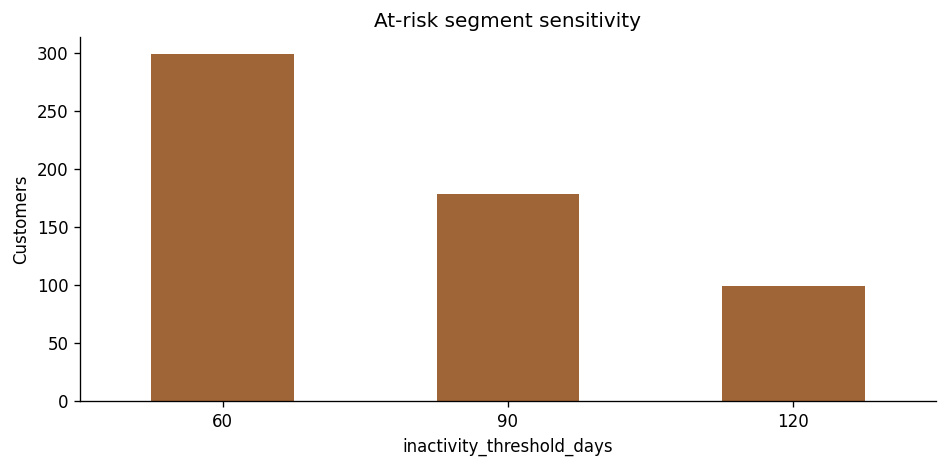

In [4]:

detail=pd.DataFrame([{'inactivity_threshold_days':d,'at_risk_customers':int(((rfm.recency_days>d)&(rfm.monetary>=500)).sum()),'historical_spend':rfm.loc[(rfm.recency_days>d)&(rfm.monetary>=500),'monetary'].sum()} for d in [60,90,120]]).set_index('inactivity_threshold_days')
display(detail.round(2))
fig,ax=plt.subplots(figsize=(8,4));detail.at_risk_customers.plot.bar(ax=ax,color='#a06536',rot=0);ax.set_ylabel('Customers');ax.set_title('At-risk segment sensitivity');fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
recommendation=f'Using a 90-day inactivity rule identifies {detail.loc[90,"at_risk_customers"]:,.0f} high-value customers. Validate response to outreach before scaling; historical spend is not recoverable revenue.'

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,customers,revenue,median_recency
segment,,,
At risk high value,179,138296.02,124.0
Champions,295,288659.54,18.0
Developing,776,414375.22,58.0
One-time,43,6046.13,147.0


,value
Customers,1293.000000
At-risk customers,179.000000
Top 20% revenue share (%),36.734921


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['customers', 'revenue']


,segment,customers,revenue
0,At risk high value,179,138296.02
1,Champions,295,288659.54
2,Developing,776,414375.22
3,One-time,43,6046.13


## Visual interpretation

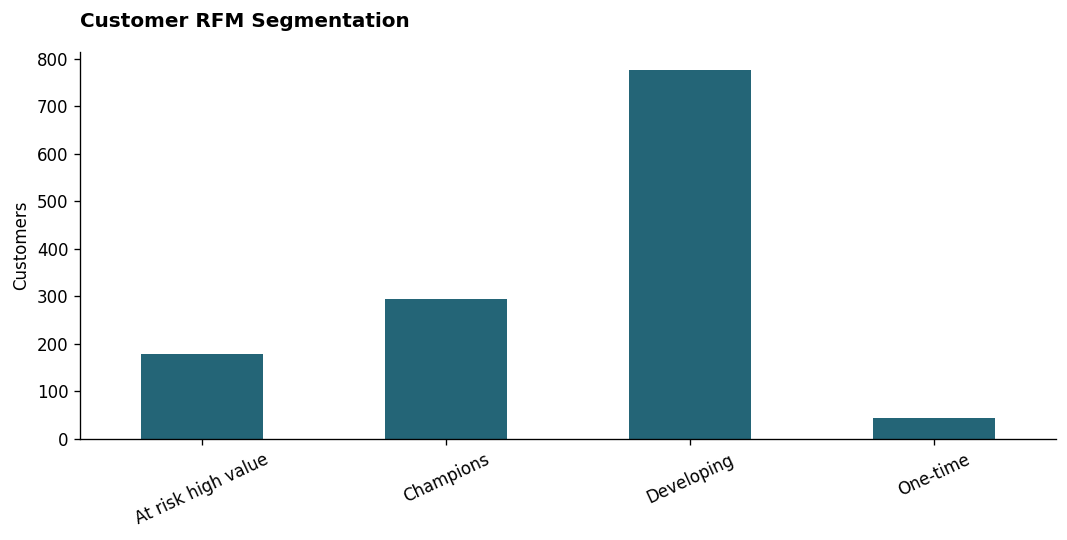

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('Customer RFM Segmentation',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Customer RFM Segmentation</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>Customer RFM Segmentation</h1><p>Which customers deserve retention attention?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>Segments reflect chosen thresholds and the observation window. They do not predict response or lifetime value.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

Segments reflect chosen thresholds and the observation window. They do not predict response or lifetime value.

**Next step:** Test segment-specific messaging with a randomized control and consented contact data.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.